### **1. Distribuzioni di probabilità**
Genera 1000 valori casuali da una distribuzione gamma con parametro di forma pari a 1.
Suggerimento: il parametro di forma viene passato come primo argomento quando si "congela" la distribuzione.

Traccia l’istogramma del campione e sovrapponi la PDF della distribuzione.

Stima il parametro di forma dal campione usando il metodo fit.

Extra:
Le distribuzioni hanno molti metodi utili. Esplorali usando il completamento automatico con il tasto TAB.

Traccia la funzione di distribuzione cumulativa (CDF).

Calcola la varianza.

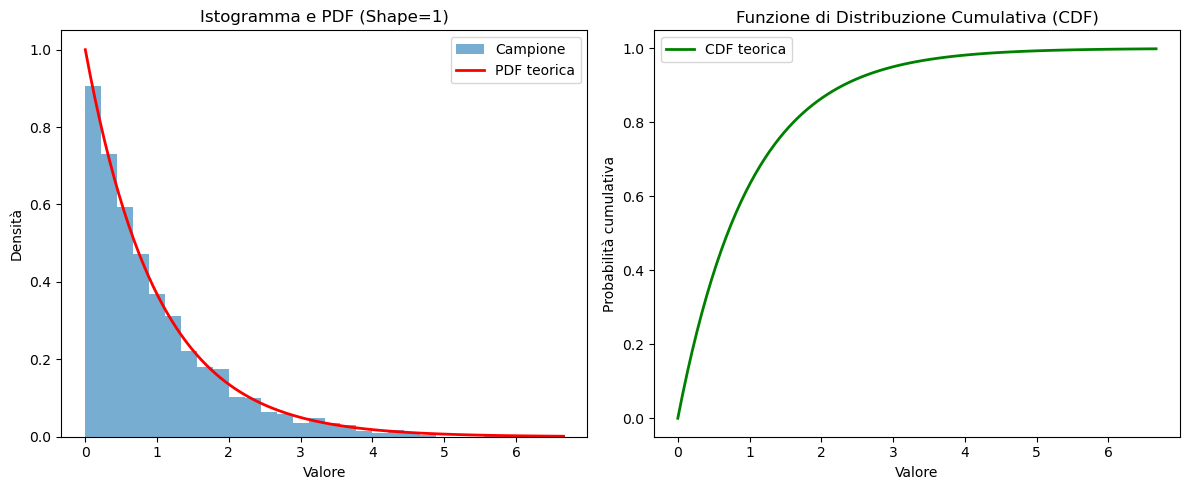

Parametro di forma stimato: 0.9753
Varianza del campione:      0.8706
Varianza teorica:           1.0000


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp


shape_param = 1                           # gamma con alfa = 1 è un'esponenziale
rv = sp.stats.gamma(a= shape_param)       # creo estrazione gamma
data = rv.rvs(size=1000)                  # con rvs prendo un sample di 1000


plt.figure(figsize=(12, 5))


plt.subplot(1, 2, 1)
count, bins, ignored = plt.hist(data, bins=30, density=True, alpha=0.6, label='Campione')

# Genero i punti per la PDF teorica
x = np.linspace(0, np.max(data), 100)
pdf = rv.pdf(x)
plt.plot(x, pdf, 'r-', lw=2, label='PDF teorica')

plt.title(f'Istogramma e PDF (Shape={shape_param})')
plt.xlabel('Valore')
plt.ylabel('Densità')
plt.legend()

# Traccio la CDF (Funzione di distribuzione cumulativa)
plt.subplot(1, 2, 2)
cdf = rv.cdf(x)
plt.plot(x, cdf, 'g-', lw=2, label='CDF teorica')

plt.title('Funzione di Distribuzione Cumulativa (CDF)')
plt.xlabel('Valore')
plt.ylabel('Probabilità cumulativa')
plt.legend()


plt.show()

# STIMO IL parametro di forma usando fit
shape_hat, loc_hat, scale_hat = gamma.fit(data)

# Calcolo la varianza
variance_sample = np.var(data)
variance_theoretical = rv.var()


print(f"Parametro di forma stimato: {shape_hat:.4f}")
print(f"Varianza del campione:      {variance_sample:.4f}")
print(f"Varianza teorica:           {variance_theoretical:.4f}")


### **2. Fitta i dati**
Prova a fittare i dati sottostanti con le migliori curve, calcola il MAE e l'RMSE
Esercizio 

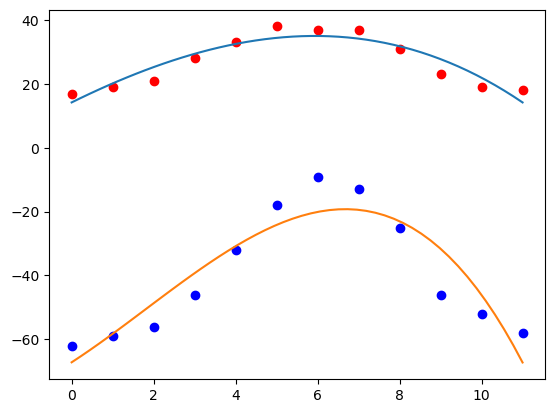

In [23]:
import numpy as np
temp_max = np.array([17, 19, 21, 28, 33, 38, 37, 37, 31, 23, 19, 18])
temp_min = np.array([-62, -59, -56, -46, -32, -18, -9, -13, -25, -46, -52, -58])
import matplotlib.pyplot as plt
import scipy as sp

months = np.arange(12)
plt.plot(months, temp_max, "ro")
plt.plot(months, temp_min, "bo")


# approssimazione con polinomio
def polinomio_3(x, a, b, c, d):
    return a*x**3 + b*x**2 + c*x + d

params_max, _ = sp.optimize.curve_fit(polinomio_3, months, temp_max)
params_min, _ = sp.optimize.curve_fit(polinomio_3, months, temp_min)


x = np.linspace(0,11)
plt.plot(x, polinomio_3(x, *params_max))
plt.plot(x, polinomio_3(x, *params_min))

plt.show()

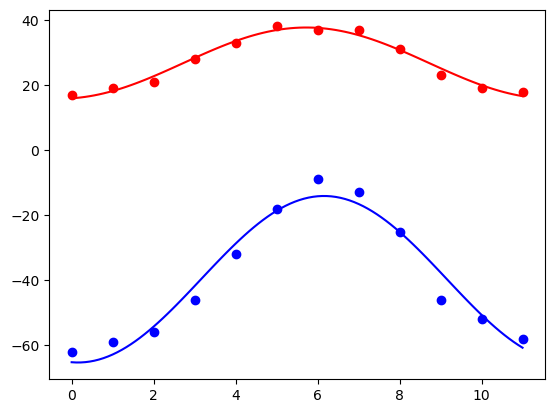

In [1]:
import numpy as np
temp_max = np.array([17, 19, 21, 28, 33, 38, 37, 37, 31, 23, 19, 18])
temp_min = np.array([-62, -59, -56, -46, -32, -18, -9, -13, -25, -46, -52, -58])
import matplotlib.pyplot as plt
import scipy as sp

temp_max = np.array([17, 19, 21, 28, 33, 38, 37, 37, 31, 23, 19, 18])
temp_min = np.array([-62, -59, -56, -46, -32, -18, -9, -13, -25, -46, -52, -58])
months = np.arange(12)

# a: ampiezza, b: sfasamento, c: offset verticale (media)
def sin_func(x, a, b, c):
    return a * np.sin((x + b) * 2 * np.pi / 12) + c

params_max, _ = sp.optimize.curve_fit(sin_func, months, temp_max, [15, 1, 20])
params_min, _ = sp.optimize.curve_fit(sin_func, months, temp_min, [25, 1, -40])

# Creazione di un array di x più fitto per una curva fluida
x_smooth = np.linspace(0, 11, 100)

plt.plot(months, temp_max, 'ro', label='Max reali')
plt.plot(months, temp_min, 'bo', label='Min reali')

plt.plot(x_smooth, sin_func(x_smooth, *params_max), 'r-', label='Fit Max')
plt.plot(x_smooth, sin_func(x_smooth, *params_min), 'b-', label='Fit Min')

plt.show()

### **3. Modello di regressione lineare dei seguenti dati**

 Calcola un modello di regressione lineare delle colonne mpg e disp del famoso dataset mtcars.

Dove: 

mpg = Miles Per Gallon → miglia per gallone, cioè una misura del consumo di carburante. Più alto è il valore, più efficiente è l’auto.

disp = Displacement → cilindrata del motore, in pollici cubici (cubic inches). Rappresenta il volume totale dei cilindri del motore. Più è alto, maggiore è la potenza potenziale del motore (ma anche il consumo).

In [4]:
import pandas as pd
import scipy as sp
import numpy as np

# Load dataset from URL
df = pd.read_csv('https://gist.githubusercontent.com/seankross/a412dfbd88b3db70b74b/raw/5f23f993cd87c283ce766e7ac6b329ee7cc2e1d1/mtcars.csv')

# Display the dataframe
df.head()



,model,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
0,Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
1,Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
2,Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
3,Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
4,Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2


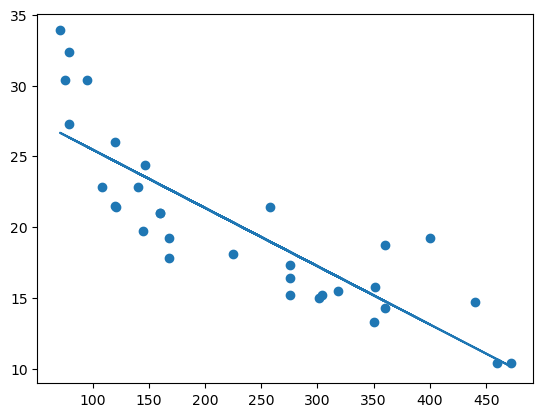

In [18]:
x = df['disp']
y = df['mpg']

# plt.plot(df.model, df.mpg, "bo")

slope, intercept, *_ = sp.stats.linregress(df['disp'], df['mpg'])

y_pred = slope*x + intercept

plt.scatter(x, y, label='True values')


plt.plot(df['disp'], y_pred)

plt.show()

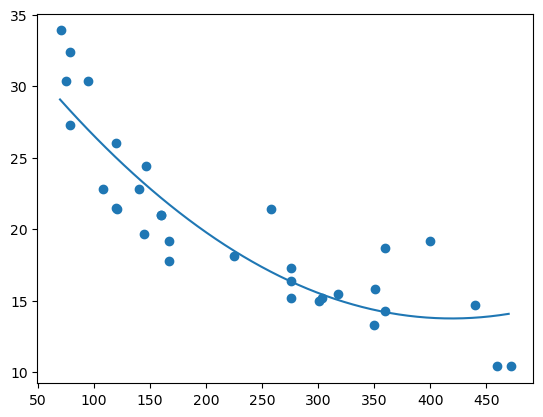

In [ ]:
x = df['disp']
y = df['mpg']

plt.scatter(x, y, label='True values')

# regressione con polinomio di secondo grado (più accurata?)

def polinomio_2(x, a, b, c):
    return  a*x**2 + b*x + c

params, _ = sp.optimize.curve_fit(polinomio_2, df['disp'], df['mpg'])

x = np.linspace(70, 470)
plt.plot(x, polinomio_2(x, *params))


plt.show()